In [ ]:
# 1. Import Library
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split, Subset
import torchvision.transforms as transforms
import torch.optim as optim

from datetime import datetime
from pathlib import Path
import inspect
import json
import time
import os

import numpy as np
import math

import pandas as pd

from typing import Dict
import copy

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from datasets import load_dataset


/mnt/nas-hpg9/eleazartadeo/miniconda3/envs/RAGFramework/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 2. Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


Shape Gambar Data Latih: (60000, 28, 28)
Shape Label Data Latih: (60000,)


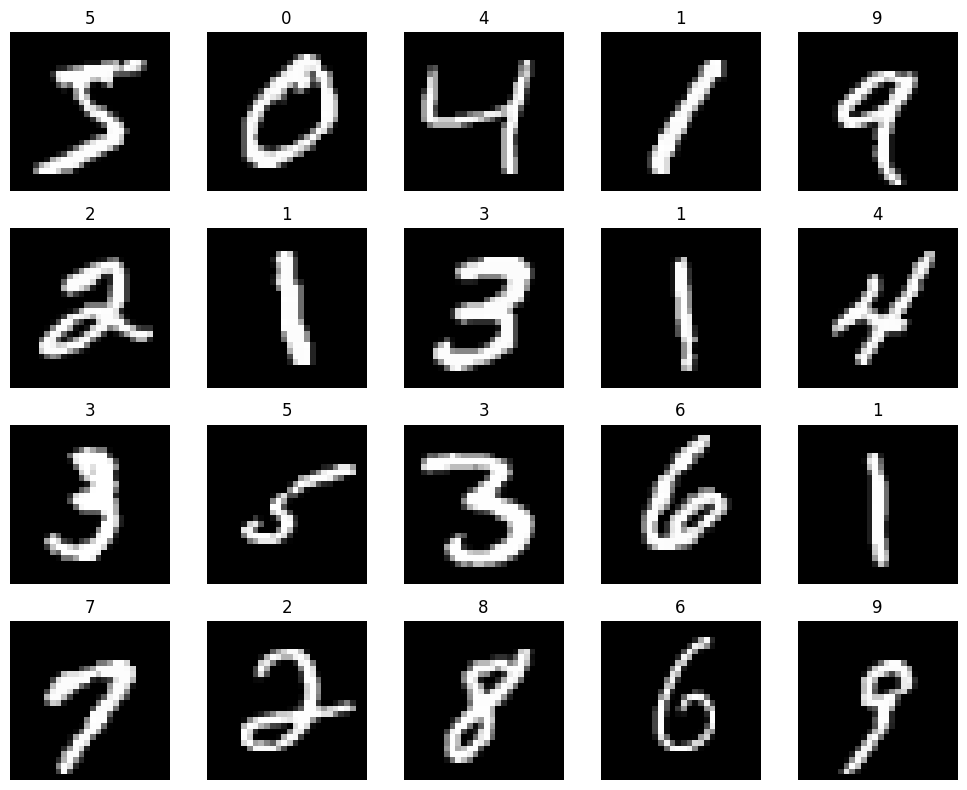

In [3]:
# 3. Load Dataset Vision
from src.image_loader import load_mnist_images, load_mnist_labels

# 3.1. Load data latih dan data uji dari file yang sudah di download
x_train = load_mnist_images("dataset/image/train-images-idx3-ubyte")
y_train = load_mnist_labels("dataset/image/train-labels-idx1-ubyte")

x_test = load_mnist_images("dataset/image/t10k-images-idx3-ubyte")
y_test = load_mnist_labels("dataset/image/t10k-labels-idx1-ubyte")

# 3.2. Print shape atau bentuk gambar dan label data latih
print(f"Shape Gambar Data Latih: {x_train.shape}")
print(f"Shape Label Data Latih: {y_train.shape}")

# 3.3. Menunjukkan contoh sampel gambar data latih beserta labelnya
rows = 4
cols = 5
fig, axes = plt.subplots(rows, cols, figsize=(10, 8))

for i in range(rows * cols):
    r = i // cols
    c = i % cols

    axes[r, c].imshow(x_train[i], cmap='gray')
    axes[r, c].set_title(y_train[i])
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# 4. Preprocessing Dataset Vision
from src.image_preprocessor import preprocess_mnist

# 4.1. Melakukan preprocessing terhadap data latih
x_train, y_train = preprocess_mnist(
    x_train,
    y_train,
    normalize=True,
    flatten=True,
    one_hot=False
)

# 4.2. Menunjukkan contoh sampel gambar data latih beserta labelnya yang sudah di preprocess
print(f"Shape Gambar Data Latih (Preprocessed): {x_train.shape}")
print(f"Shape Label Data Latih (Preprocessed): {y_train.shape}")

# 4.3. Mengubah x_train dan y_train menjadi bentuk tensor untuk dijadikan tensor dataset
x_train_tensor = torch.tensor(
    x_train,
    dtype=torch.float32,
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long,
)

# 4.4. Menjadikan x_train_tensor dan y_train_tensor menjadi tensor dataset
train_dataset = TensorDataset(
    x_train_tensor,
    y_train_tensor,
)

# 4.5. Menjadikan train_dataset menjadi sebuah data loader untuk di training
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
)


Shape Gambar Data Latih (Preprocessed): (60000, 784)
Shape Label Data Latih (Preprocessed): (60000,)


### 5. Definisi Model Generatif Vision


### 6. Penjelasan Rumus Model Vision
# TODO - Menambah penjelasan untuk tiap konsep

#### 6.1. Konsep Dasar Generative Model
Model generatif berusaha mempelajari distribusi data:

$$
p(x)
$$

atau distribusi bersyarat:

$$
p(x|c)
$$

- $x$ = data yang ingin dihasilkan, misalnya gambar atau teks.  
- $c$ = kondisi, misalnya prompt, label, atau input tertentu.  
- $p(x)$ = peluang kemunculan data.  
- $p(x|c)$ = peluang menghasilkan data berdasarkan kondisi tertentu.

##### Penjelasan:

#### 6.2. Autoencoder

$$
z = f_{\theta}(x)
$$

$$
\hat{x} = g_{\phi}(z)
$$

$$
L = \|x - \hat{x}\|^2
$$

- $x$ = input asli.  
- $z$ = latent vector.  
- $\hat{x}$ = hasil rekonstruksi.  
- $f_{\theta}$ = encoder.  
- $g_{\phi}$ = decoder.  
- $L$ = reconstruction loss.

#### 6.3. Variational Autoencoder
$$
q_{\phi}(z|x)
$$

$$
z = \mu + \sigma \cdot \epsilon
$$

$$
\epsilon \sim \mathcal{N}(0, I)
$$

$$
L = L_{\text{reconstruction}} + L_{KL}
$$

$$
L_{KL} = D_{KL}(q_{\phi}(z|x) \parallel p(z))
$$

- $\mu$ = mean latent.  
- $\sigma$ = standar deviasi latent.  
- $\epsilon$ = noise acak.  
- $q_{\phi}(z|x)$ = distribusi latent dari input.  
- $p(z)$ = distribusi prior, biasanya normal standar.  
- $D_{KL}$ = KL divergence.

#### 6.4. Generative Adversarial Network (GAN)

$$
\min_G \max_D V(D, G)
$$

$$
V(D,G)=\mathbb{E}_{x \sim p_{data}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]
$$

- $G$ = generator.  
- $D$ = discriminator.  
- $x$ = data asli.  
- $z$ = noise acak.  
- $G(z)$ = data palsu yang dibuat generator.  
- $D(x)$ = probabilitas data dianggap asli.

#### 6.5. Diffusion Model

$$
x_t = \sqrt{\alpha_t} x_0 + \sqrt{1 - \alpha_t}\,\epsilon
$$

$$
\epsilon \sim \mathcal{N}(0, I)
$$

$$
L = \|\epsilon - \epsilon_{\theta}(x_t, t)\|^2
$$

- $x_0$ = gambar asli.  
- $x_t$ = gambar yang sudah diberi noise.  
- $\epsilon$ = noise asli.  
- $\epsilon_{\theta}$ = noise yang diprediksi model.  
- $t$ = timestep.  
- $\alpha_t$ = koefisien noise.


Training VAE
Epoch [1/20] train_loss: 0.0701 | train_recon_loss: 0.0698 | train_kl_loss: 0.0003
Epoch [2/20] train_loss: 0.0672 | train_recon_loss: 0.0658 | train_kl_loss: 0.0014
Epoch [3/20] train_loss: 0.0670 | train_recon_loss: 0.0655 | train_kl_loss: 0.0015
Epoch [4/20] train_loss: 0.0670 | train_recon_loss: 0.0654 | train_kl_loss: 0.0016
Epoch [5/20] train_loss: 0.0669 | train_recon_loss: 0.0653 | train_kl_loss: 0.0016
Epoch [6/20] train_loss: 0.0669 | train_recon_loss: 0.0653 | train_kl_loss: 0.0016
Epoch [7/20] train_loss: 0.0668 | train_recon_loss: 0.0652 | train_kl_loss: 0.0016
Epoch [8/20] train_loss: 0.0668 | train_recon_loss: 0.0652 | train_kl_loss: 0.0016
Epoch [9/20] train_loss: 0.0669 | train_recon_loss: 0.0653 | train_kl_loss: 0.0016
Epoch [10/20] train_loss: 0.0668 | train_recon_loss: 0.0652 | train_kl_loss: 0.0016
Epoch [11/20] train_loss: 0.0668 | train_recon_loss: 0.0652 | train_kl_loss: 0.0016
Epoch [12/20] train_loss: 0.0668 | train_recon_loss: 0.0652 | train_kl_l

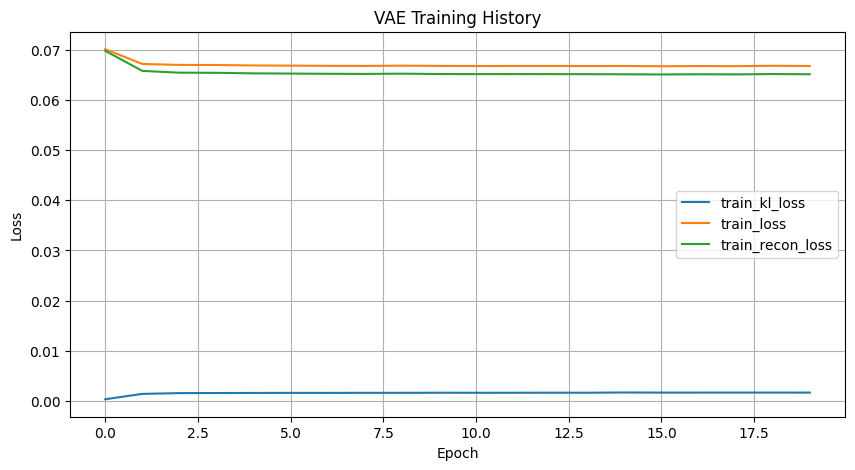

Training GAN
Epoch [1/20] train_g_loss: 3.2144 | train_d_loss: 0.3049
Epoch [2/20] train_g_loss: 5.9595 | train_d_loss: 0.0173
Epoch [3/20] train_g_loss: 6.9833 | train_d_loss: 0.0060
Epoch [4/20] train_g_loss: 7.4669 | train_d_loss: 0.0099
Epoch [5/20] train_g_loss: 8.6381 | train_d_loss: 0.0164
Epoch [6/20] train_g_loss: 7.2159 | train_d_loss: 0.0084
Epoch [7/20] train_g_loss: 8.9415 | train_d_loss: 0.0096
Epoch [8/20] train_g_loss: 9.4011 | train_d_loss: 0.0041
Epoch [9/20] train_g_loss: 8.5577 | train_d_loss: 0.0085
Epoch [10/20] train_g_loss: 11.5825 | train_d_loss: 0.0168
Epoch [11/20] train_g_loss: 8.8655 | train_d_loss: 0.0068
Epoch [12/20] train_g_loss: 12.2689 | train_d_loss: 0.0075
Epoch [13/20] train_g_loss: 14.8577 | train_d_loss: 0.0126
Epoch [14/20] train_g_loss: 15.7037 | train_d_loss: 0.0140
Epoch [15/20] train_g_loss: 10.3499 | train_d_loss: 0.0063
Epoch [16/20] train_g_loss: 10.5314 | train_d_loss: 0.0043
Epoch [17/20] train_g_loss: 14.5824 | train_d_loss: 0.0095
Epo

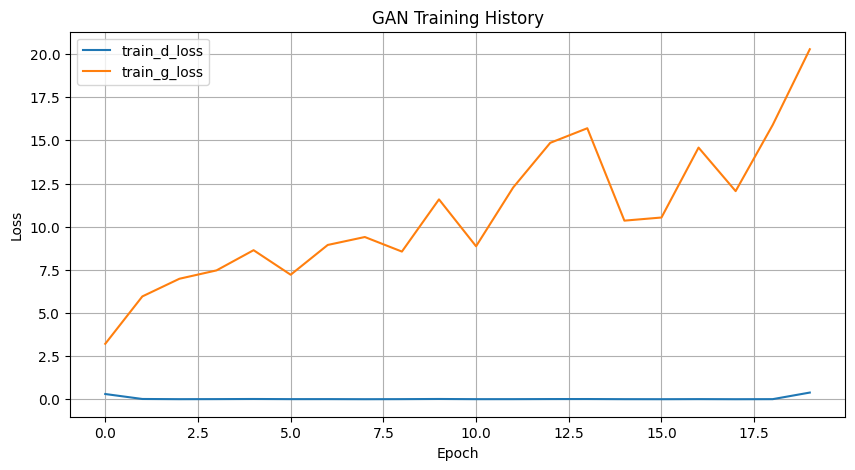

In [5]:
# 7. Training Model Vision
from src.image_generators import VAE, GAN
from src.image_train import image_train

# 7.1. Membuat dictionary model yang digunakan beserta confignya
models = {
        VAE: {
            'latent_dim': 128,
            'hidden_dim': 128,
            'epochs': 20,
        },
        GAN: {
            'latent_dim': 128,
            'hidden_dim': 128,
            'epochs': 20,
        }
    }

# 7.2. Membuat dictionary history kosong untuk menyimpan semua hasil training eksperimen image generation
histories = {}

# 7.3. Membuat folder untuk menyimpan semua gambar dan hasil eksperimen (berlaku untuk teks juga)
def get_timestamp() -> str:
    return datetime.now().strftime("%Y%m%d-%H%M%S")

def create_folder(path:str) -> str:
    os.makedirs(path, exist_ok=True)
    return path

run_path = create_folder(f"outputs/run-{get_timestamp()}")

# 7.3.1. Membuat folder untuk menyimpan semua gambar dan hasil eksperimen khusus image
image_path = create_folder(f"{run_path}/image/")
history_image_path = create_folder(f"{image_path}/history")

# 7.4. Melakukan proses training dan menyimpan hasil model beserta historynya kedalam dictionary histories
for model_class, config in models.items():
    model = model_class(
        input_dim=x_train.shape[1],
        latent_dim=config["latent_dim"],
        hidden_dim=config["hidden_dim"],
        device=device
    ).to(device)
    print("="*75)
    print(f"Training {str(model)}")
    print("="*75)

    # 7.4.1. Melakukan proses training dengan menunjukkan proses epoch beserta lossnya, dan diakhiri visualisasi grafik training history
    history = image_train(
        model=model,
        train_loader=train_loader,
        epochs=config['epochs'],
        verbose=True,
        history_image_path = history_image_path,
    )

    histories[model] = history


In [6]:
# 8. Generate Gambar Baru

# 8.1. Menentukan berapa banyak sampel yang ingin digenerasi dengan variabel rows dan column, agar bisa disesuaikan ingin seberapa banyak
rows = 4
cols = 5

# 8.2. Menyimpan semua sampel kedalam dicitonary untuk nantinya digunakan dalam # 9. Visualisasi Hasil Vision
all_samples = {}
for model, history in histories.items():
    samples = model.generate(rows*cols)
    print(f"Generated {len(samples)} images from {str(model)} model")
    all_samples[str(model)] = samples

Generated 20 images from VAE model
Generated 20 images from GAN model


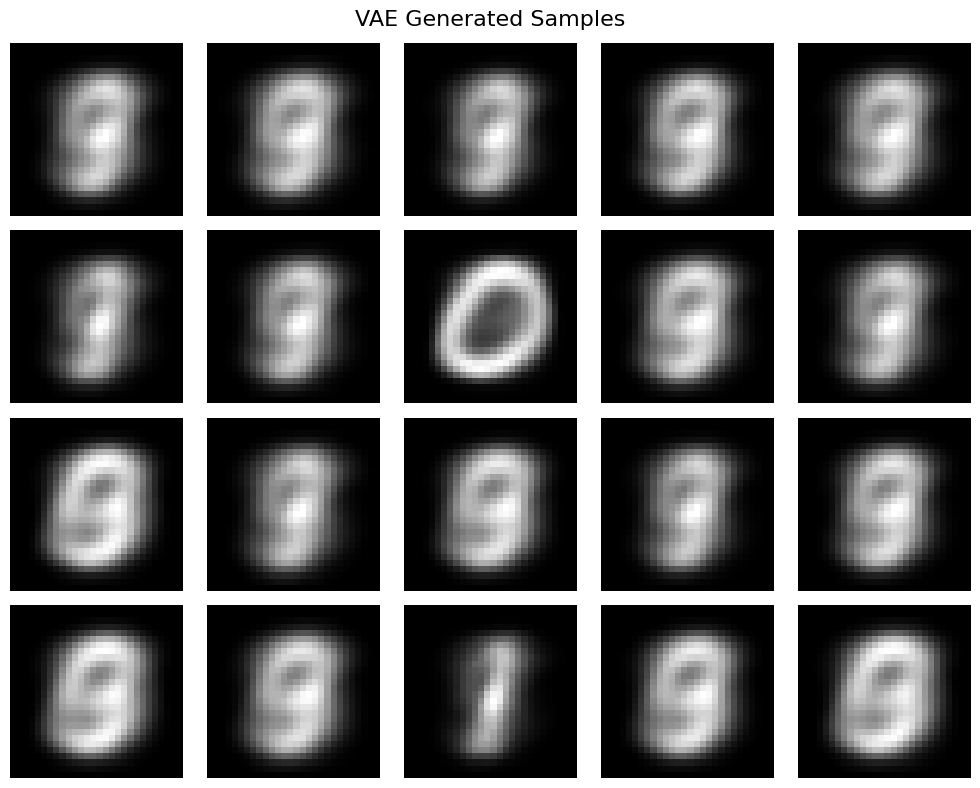

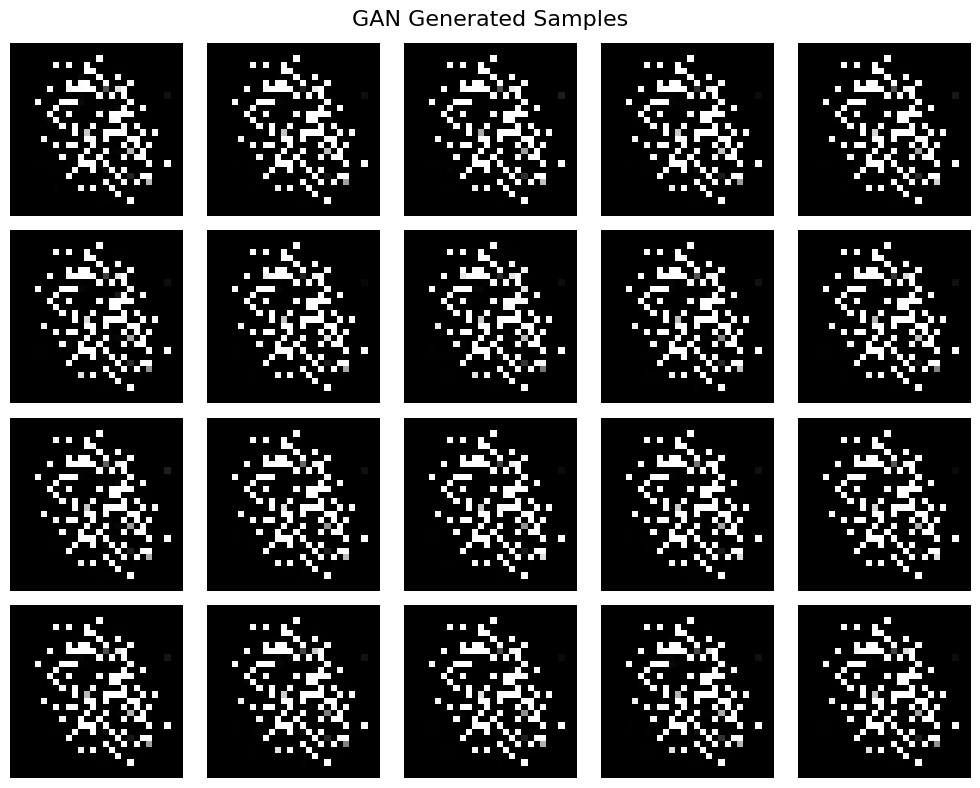

In [8]:
# 9. Visualisasi Hasil Vision

# 9.1. Iterasi untuk setiap model yang digunakan beserta sampel yang digenerasi sesuai dengan ketentuan jumlah sampel
# yang sudah didefinisikan sebelumnya, menampilkan gambar hasil generasi untuk perbandingan

generated_image_path = create_folder(f"{image_path}/generated")
for model_name, samples in all_samples.items():
    fig, axes = plt.subplots(rows, cols, figsize=(10, 8))

    for i in range(rows*cols):
        r = i // cols
        c = i % cols

        axes[r, c].imshow(samples[i][0], cmap="gray")
        axes[r, c].axis("off")
        
    fig.suptitle(f"{model_name} Generated Samples", fontsize=16)
    plt.tight_layout()
    plt.savefig(f"{generated_image_path}/{model_name}-generated-samples.png", dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
# 10. Load Dataset Text

In [ ]:
# 11. Preprocessing Text

### 12. Definisi Model Generatif Text

### 13. Penjelasan Rumus Model Text
#### 13.1. Text Generation

Text generation dilakukan dengan memprediksi token satu per satu:

$$
p(x_1, x_2, ..., x_T) = \prod_{t=1}^{T} p(x_t \mid x_1, x_2, ..., x_{t-1})
$$

- $x_t$ = token pada posisi ke-$t$.  s
- $x_1, ..., x_{t-1}$ = token sebelumnya.  
- Model memprediksi token berikutnya berdasarkan token sebelumnya.

#### 13.2. Self-Attention Transformer

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

- $Q$ = query.  
- $K$ = key.  
- $V$ = value.  
- $d_k$ = dimensi key.  
- $\text{softmax}$ = mengubah skor menjadi bobot perhatian.

#### 13.3. Cross Entropy Loss untuk Text Generation

$$
L = -\sum_{i=1}^{N} y_i \log(\hat{y}_i)
$$

- $y_i$ = token target sebenarnya.  
- $\hat{y}_i$ = probabilitas token hasil prediksi.  
- $N$ = jumlah token atau vocabulary class.

In [ ]:
# 14. Training Model Text

In [ ]:
# 15. Generate Text dari Prompt

In [ ]:
# 16. Visualisasi Loss

In [ ]:
# 17. Perbandingan Hasil

### 18. Analisis

### 19. Kesimpulan